In [1]:
import xarray as xr
import pandas as pd
import glob
import os
import math

import numpy as np
import re
from joblib import Parallel, delayed
from pathlib import Path
import matplotlib.pyplot as plt

In [1]:
#pip install -e ..


Defaulting to user installation because normal site-packages is not writeable
Obtaining file:///glade/u/home/qingyuany/repos/spatialtuning
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Using cached xarray-2025.6.1-py3-none-any.whl.metadata (12 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scipy-1.15.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached scikit_learn-1.7.2-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached shapely-2.1.2-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (6.8 kB)
  Using cached alphashape-1.3.1-py2.py3-none-any.whl.metadata (18 kB)
  Using cached click_log-0.4.0-py2.py3-none-any.whl.metadata (1.2 kB)


In [2]:
from proj2dhullsampler import HistoryMatching

In [3]:
obs = xr.open_dataset('/glade/work/fanda/miles-climatesleuth/microphysics_analysis/data/satellite_climatologies_withuncertainty360nlon180nlat_updatedMar2026.nc')
obs = obs.mean(dim = "mos").sel(obstype = 1)
obs['pr'] = obs['pr']/(1000 * 86400)

In [4]:
working_dir = '/glade/work/qingyuany/repo_data/'
case_name = "test_v1"


obs_dict = {"SWCF": "swcrf_toa", "LWCF": "lwcrf_toa", "TGCLDLWP": "tlwp", "TMQ": "pwv",
          "FLUT": "olr", "PRECT": "pr","FSNTOA": "swabs_toa"}


In [5]:
ppe = xr.open_dataset("/glade/work/qingyuany/camml_re/v3_extreme/post_simulations/batch_filter_v3.nc")

In [6]:
obs_interp = obs.interp(
    lat=ppe["lat"],
    lon=ppe["lon"]
)

obs_interp = obs_interp[list(obs_dict.values())]
obs_interp = obs_interp.drop_vars('obstype')

In [7]:
para = pd.read_csv("/glade/work/qingyuany/camml_re/v3_extreme/post_simulations/post_paras.csv", index_col=0)
para.head()



,micro_mg_max_nicons,micro_mg_vtrmi_factor,micro_mg_iaccr_factor,micro_mg_berg_eff_factor,micro_mg_accre_enhan_fact,micro_mg_homog_size,micro_mg_dcs,clubb_c1,clubb_C8,clubb_c11,...,zmconv_capelmt,seasalt_emis_scale,dust_emis_fact,sol_factb_interstitial,sol_factic_interstitial,microp_aero_wsub_min,microp_aero_wsubi_min,microp_aero_wsub_scale,microp_aero_wsubi_scale,microp_aero_npccn_scale
1,8.764451e+09,0.734829,0.504504,0.660242,0.583751,0.000041,0.000231,2.397564,4.297589,0.520757,...,101.458370,0.642010,0.440628,0.224962,0.838330,0.102638,0.147649,4.601857,3.895177,2.947053
2,6.249091e+09,0.719602,0.451698,0.623707,4.913654,0.000178,0.000216,2.094584,3.640743,0.392219,...,89.033010,1.147832,0.284604,0.790406,0.334195,0.078667,0.133590,3.908127,2.368320,2.932574
3,3.643257e+09,0.734745,0.631602,0.602616,3.506507,0.000058,0.000234,2.936606,4.589038,0.647695,...,74.284987,1.691183,0.121225,0.210095,0.945064,0.183940,0.022292,2.124240,2.945122,1.680474
4,7.799491e+09,0.867221,0.449595,0.698135,3.682035,0.000031,0.000236,0.483083,3.766823,0.356188,...,76.816492,1.891392,0.760065,0.800012,0.472317,0.240086,0.186566,2.662161,2.162034,1.920328
5,3.249013e+09,0.996169,0.395150,0.731877,7.910945,0.000163,0.000216,2.104301,4.542901,0.281722,...,98.345530,1.820523,0.252576,0.662260,0.698986,0.479244,0.034171,2.748193,4.844915,1.837668


In [8]:

obs_precip_freq = pd.read_csv('/glade/work/qingyuany/camml_re/v0/filtered_obs_precip_freq.csv', index_col = 0)
obs_precip_freq = obs_precip_freq.iloc[:,0]
ppe_precip_freq = pd.read_csv('/glade/work/qingyuany/camml_re/v3_extreme/post_simulations/filtered_extreme_precip.csv', index_col=0)

In [9]:
ppe_precip_freq

,filter_precip099,filter_precip0999,filter_precip09999
1,373.533346,503.158143,625.515229
2,375.951889,513.124566,627.941763
3,376.102260,518.649713,636.266978
4,366.566361,493.989113,595.864959
5,400.901404,546.963794,665.939865
...,...,...,...
96,402.632969,538.313260,665.171162
97,420.002607,579.685060,719.637508
98,338.496496,456.733961,577.270153
99,413.740035,570.667076,690.836907


In [10]:
lat_bins = np.arange(-75, 76, 60)  # -90 to 90 every 10 degrees

In [11]:
man_sel_locations1 = pd.Series({"nm": "PRECT", "lat_min": 4,"lat_max": 7, "lon_min":  1, "lon_max": 359})
man_sel_locations2 = pd.Series({"nm": "SWCF", "lat_min": 4,"lat_max": 7, "lon_min":  1, "lon_max": 359})

manul_ppe_info = pd.concat([man_sel_locations1, man_sel_locations2], axis  = 1).transpose()
manul_ppe_info

,nm,lat_min,lat_max,lon_min,lon_max
0,PRECT,4,7,1,359
1,SWCF,4,7,1,359


In [12]:
weights = np.cos(np.deg2rad(obs_interp.lat))
weights = weights / weights.mean()

ppe_global = ppe[['SWCF', 'LWCF', 'FLUT', 'FSNTOA']].weighted(weights).mean(dim = ["lat", "lon"]).to_dataframe()
obs_global = obs_interp[['swcrf_toa', 'lwcrf_toa', 'olr', 'swabs_toa']].weighted(weights).mean(dim = ["lat", "lon"]).to_array().to_series()

ppe_global.columns = ['ave_SWCF', 'ave_LWCF', 'ave_FLUT', 'ave_FSNTOA'] 
obs_global.index = ['ave_SWCF', 'ave_LWCF', 'ave_FLUT', 'ave_FSNTOA'] 

In [13]:
ppe_global = pd.concat([ppe_global, ppe_precip_freq], axis = 1)
obs_global = pd.concat([obs_global, obs_precip_freq])

In [14]:
manul_ppe_info

,nm,lat_min,lat_max,lon_min,lon_max
0,PRECT,4,7,1,359
1,SWCF,4,7,1,359


In [4]:

# test_case = Prepare_Case(working_dir, case_name, 
#                 para, [ppe_global, obs_global], ppe, obs_interp, obs_dict,
#                 lat_bins, manul_ppe_info, n_sample = 1000000)


test_case = HistoryMatching(working_dir, case_name)

In [16]:
test_case.create_case(para, [ppe_global, obs_global], ppe, obs_interp, obs_dict,
                     lat_bins, manul_ppe_info, n_sample = 1000000)




Start creating new case
Check on nan variables passes: nan variables matching between obs and simulation
obs_shape: (14,), and ppe shape: (99, 14)
Manual and zonal indices match
Tabulated and processed data indices match
obs and ppe variable names match


In [17]:
test_case.prep_case.sensitivity_emulation(n_cpus=4)

/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn

In [5]:
test_case.load_case()


In [23]:
test_case.create_mask(threshold_level=2.0)
test_case.create_mask(threshold_level=3.0)


In [8]:
test_case.load_mask(threshold_level=2.0)


['local_PRECT_4_7_1_359',
 'PRECT_zonal_-75to-15',
 'ave_LWCF',
 'FLUT_zonal_-75to-15',
 'TGCLDLWP_zonal_-75to-15',
 'ave_SWCF',
 'filter_precip09999',
 'FSNTOA_zonal_-75to-15',
 'TMQ_zonal_-75to-15',
 'LWCF_zonal_-15to45',
 'SWCF_zonal_-75to-15',
 'FSNTOA_zonal_-15to45',
 'filter_precip0999',
 'local_SWCF_4_7_1_359',
 'ave_FLUT',
 'filter_precip099',
 'TGCLDLWP_zonal_-15to45',
 'LWCF_zonal_-75to-15',
 'PRECT_zonal_-15to45',
 'ave_FSNTOA',
 'TMQ_zonal_-15to45',
 'SWCF_zonal_-15to45',
 'FLUT_zonal_-15to45']

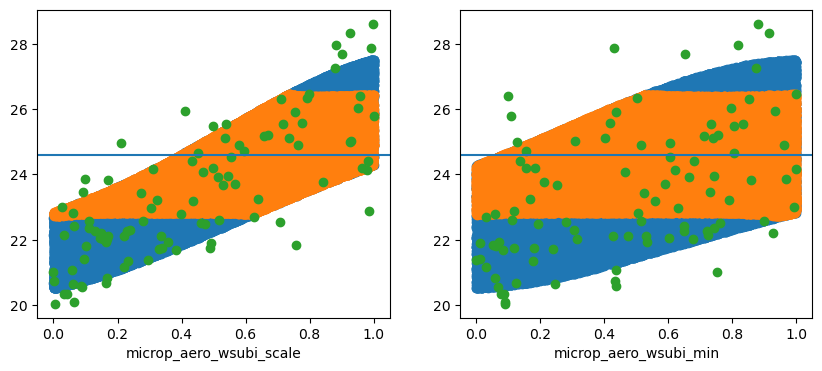

In [19]:
test_case.visualize_check('LWCF_zonal_-75to-15')

In [21]:
test_case.specifications.uncertainty_threshold

2.0

In [23]:
test_case.data_ppe.shape

(99, 23)

In [31]:
test_case.drop_by_n_survive(n_survive = 10000)
test_case.update_meta()


In [32]:
test_case.group_para_climatology(overlapping_threshold = 10000)
summary2d = test_case.shuffle_vars()

cldfrc_dp1                               and microp_aero_wsubi_scale                 :        0
clubb_c1                                 and microp_aero_wsubi_scale                 :   109360
zmconv_capelmt                           and microp_aero_wsubi_scale                 :   250063
There are 1 groups that have no overlapping within own groups


In [34]:
list(summary2d.values())[0]

,var1,var2,count
6,FLUT_zonal_-75to-15,PRECT_zonal_-15to45,0
9,ave_FLUT,PRECT_zonal_-15to45,0
13,PRECT_zonal_-15to45,FLUT_zonal_-15to45,0
12,PRECT_zonal_-15to45,TMQ_zonal_-15to45,10500
2,ave_LWCF,PRECT_zonal_-15to45,11705
5,FLUT_zonal_-75to-15,ave_FLUT,390102
0,ave_LWCF,FLUT_zonal_-75to-15,394494
7,FLUT_zonal_-75to-15,TMQ_zonal_-15to45,394512
8,FLUT_zonal_-75to-15,FLUT_zonal_-15to45,394512
10,ave_FLUT,TMQ_zonal_-15to45,400356


In [36]:
no_overlap_2d_vars = ['FLUT_zonal_-75to-15', 'PRECT_zonal_-15to45']

In [24]:
test_case.visualize_check('FLUT_zonal_35to45')

TypeError: Prepare_Case.visualize_check() missing 1 required positional argument: 'threshold'

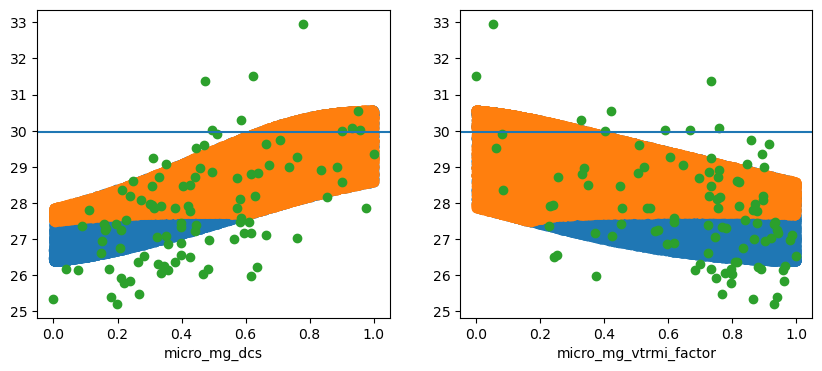

In [45]:
test_case.visualize_check('LWCF_zonal_-55to-45')

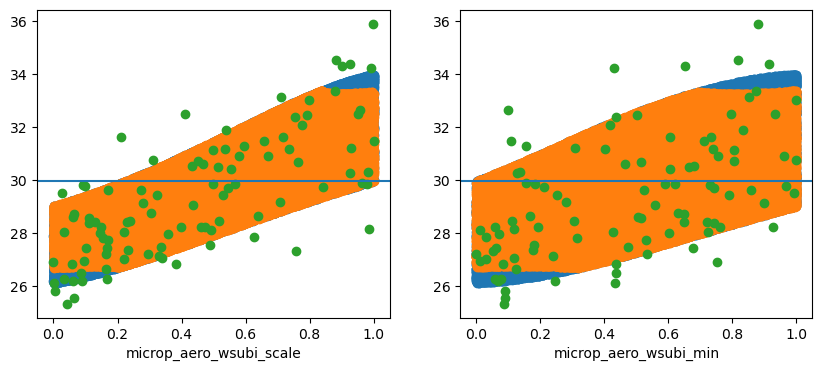

In [90]:
test_case.visualize_check('LWCF_zonal_-55to-45')